# 01 — Scribble-Based Colorization Pipeline

**Method:** Levin, Lischinski & Weiss — *Colorization using Optimization* (SIGGRAPH 2004)  
**Core idea:** Neighboring pixels with similar luminance should share similar chrominance. The user annotates sparse color scribbles; the algorithm propagates them by minimizing a quadratic cost function where affinity between pixels decays as luminance difference grows.

---
**Algorithm steps:**
1. Convert grayscale → YUV
2. Build N×N sparse affinity matrix W using correlation-based weights (eq. 3 from paper)
3. User provides scribbled pixels as color constraints
4. Solve linear system `(I − W) C = 0` subject to scribble constraints — independently for U and V channels
5. Reconstruct BGR image from solved YUV

This notebook also demonstrates the **automatic scribble generator** with controllable density.

In [13]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.scribble.colorizer import ScribbleColorizer
from src.scribble.scribble_generator import AutoScribbleGenerator

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print('Imports OK')

Imports OK


No benchmark images found — using synthetic test image.


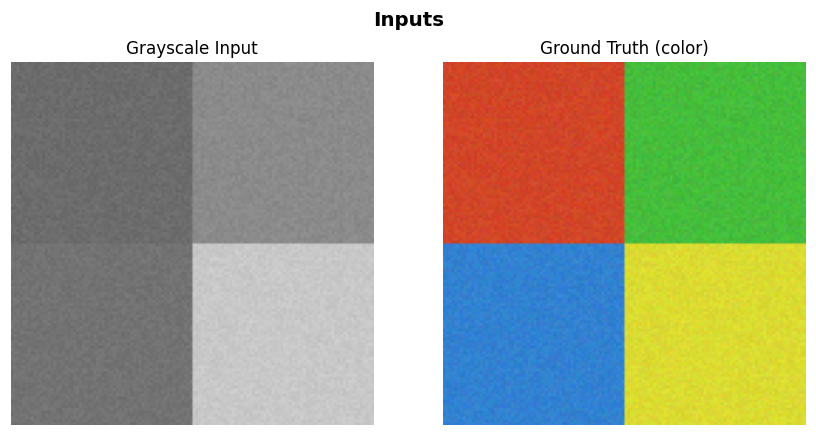

Image size: (128, 128)


In [14]:
# ── Helper: generate synthetic colorful test image ───────────────────────────
def _make_synthetic(size=128, seed=42):
    """4-quadrant colorful image with slight noise."""
    rng = np.random.RandomState(seed)
    img = np.zeros((size, size, 3), dtype=np.uint8)
    h, w = size // 2, size // 2
    img[:h, :w]  = [30,  60,  200]   # BGR: red-ish
    img[:h, w:]  = [50,  180,  60]   # BGR: green-ish
    img[h:, :w]  = [200, 120,  40]   # BGR: blue-ish
    img[h:, w:]  = [40,  210, 210]   # BGR: yellow-ish
    noise = rng.randint(0, 20, img.shape, dtype=np.uint8)
    return np.clip(img.astype(np.int32) + noise, 0, 255).astype(np.uint8)


# ── Try real COCO images; fall back to synthetic ──────────────────────────────
BENCHMARK_DIR = '../data/raw/coco2017/benchmark'
VAL_DIR       = '../data/raw/coco2017/val2017'

target_bgr_gt = None

for search_dir in [BENCHMARK_DIR, VAL_DIR]:
    if not os.path.isdir(search_dir):
        continue
    jpgs = sorted(f for f in os.listdir(search_dir) if f.lower().endswith('.jpg'))
    if jpgs:
        # Use a small crop/resize for speed
        target_bgr_gt = cv2.resize(cv2.imread(os.path.join(search_dir, jpgs[0])), (128, 128))
        print(f'Loaded real image from {search_dir}: {jpgs[0]}')
        break

if target_bgr_gt is None:
    print('No benchmark images found — using synthetic test image.')
    target_bgr_gt = _make_synthetic(128, seed=7)

gray_1ch  = cv2.cvtColor(target_bgr_gt, cv2.COLOR_BGR2GRAY)
gray_bgr  = cv2.cvtColor(gray_1ch, cv2.COLOR_GRAY2BGR)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, img, title in zip(axes,
                          [gray_bgr, target_bgr_gt],
                          ['Grayscale Input', 'Ground Truth (color)']):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle('Inputs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Image size: {gray_bgr.shape[:2]}')

## Automatic Scribble Generation

The `AutoScribbleGenerator` samples color pixels from the ground-truth image and places them as scribble constraints. The key parameter `density` controls what fraction of pixels are kept as scribbles:

- `density=0.01` → ~1% of pixels — very sparse, tests propagation quality
- `density=0.05` → ~5% — typical use-case
- `density=0.20` → ~20% — dense, near-perfect reconstruction expected

Sampling can be **uniform** (random pixels) or **edge-guided** (bias toward region boundaries for better propagation).

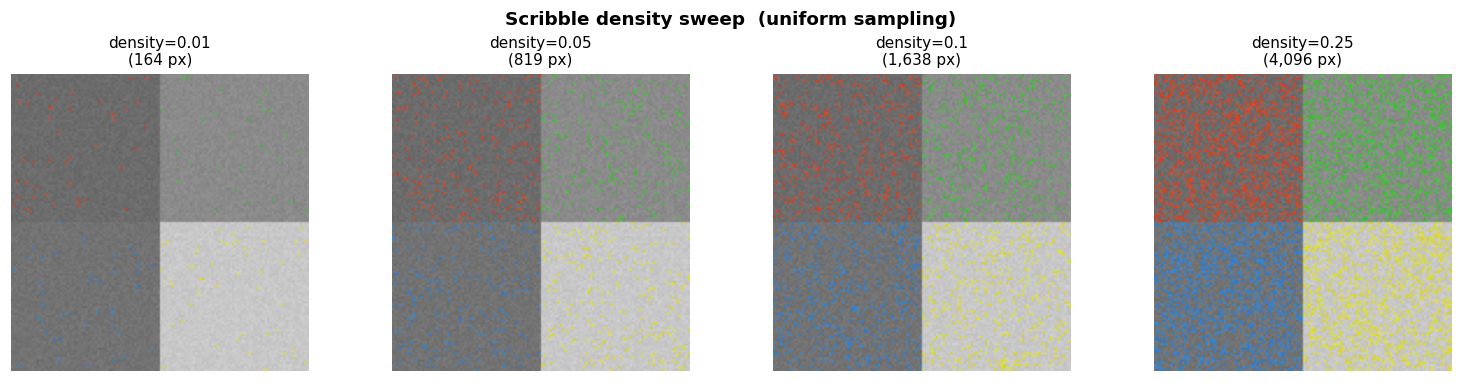

In [15]:
# ── Visualise scribble density sweep ─────────────────────────────────────────
gen = AutoScribbleGenerator(seed=0)

densities = [0.01, 0.05, 0.10, 0.25]

fig, axes = plt.subplots(1, len(densities), figsize=(14, 3.5))
for ax, d in zip(axes, densities):
    scribble_bgr = gen.generate(target_bgr_gt, gray_bgr, density=d, mode='uniform')
    n_scr = int(np.any(scribble_bgr.astype(np.int32) !=
                       gray_bgr.astype(np.int32), axis=-1).sum())
    ax.imshow(cv2.cvtColor(scribble_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(f'density={d}\n({n_scr:,} px)', fontsize=10)
    ax.axis('off')
plt.suptitle('Scribble density sweep  (uniform sampling)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

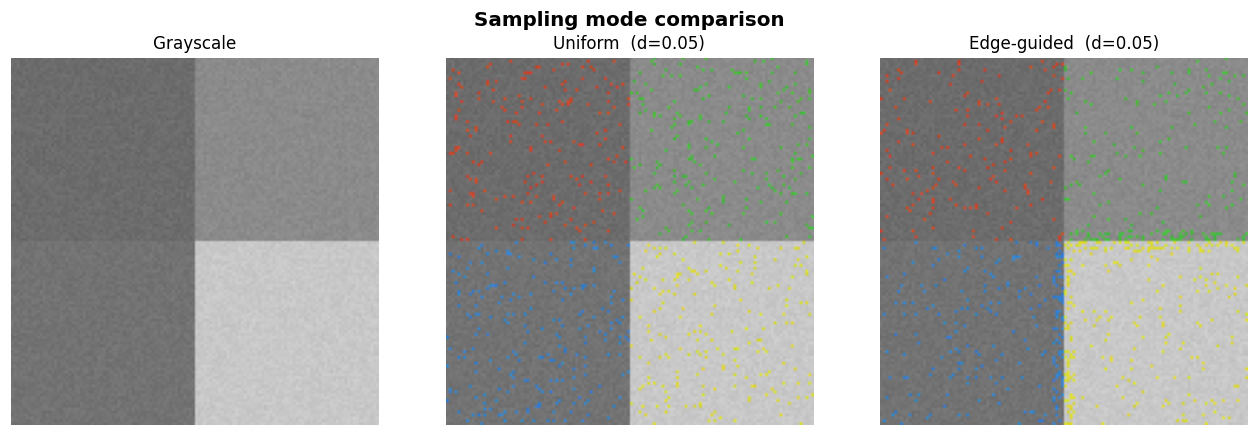

In [16]:
# ── Compare uniform vs edge-guided scribbles ─────────────────────────────────
gen = AutoScribbleGenerator(seed=42)
DENSITY = 0.05

scr_uniform = gen.generate(target_bgr_gt, gray_bgr, density=DENSITY, mode='uniform')
scr_edge    = gen.generate(target_bgr_gt, gray_bgr, density=DENSITY, mode='edge')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes,
                          [gray_bgr, scr_uniform, scr_edge],
                          ['Grayscale',
                           f'Uniform  (d={DENSITY})',
                           f'Edge-guided  (d={DENSITY})']):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle('Sampling mode comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Running the Scribble Colorizer

In [30]:
# ── Colorize with ScribbleColorizer ──────────────────────────────────────────
colorizer = ScribbleColorizer()
gen       = AutoScribbleGenerator(seed=0)

DENSITY = 0.1
scribble_bgr = gen.generate(target_bgr_gt, gray_bgr, density=DENSITY, mode='edge')

colorized_bgr, info = colorizer.colorize(gray_bgr, scribble_bgr)

print('info_dict:')
for k, v in info.items():
    print(f'  {k}: {v}')

assert colorized_bgr.shape == gray_bgr.shape,   'Output shape mismatch'
assert colorized_bgr.dtype == np.uint8,          'Output dtype must be uint8'
assert {'method', 'time_seconds', 'image_size', 'n_scribbled'} <= set(info.keys()), \
    'Missing required info keys'
print('\nAll assertions passed.')

info_dict:
  method: scribble_based
  time_seconds: 3.1482186317443848
  image_size: (128, 128)
  n_scribbled: 1638

All assertions passed.


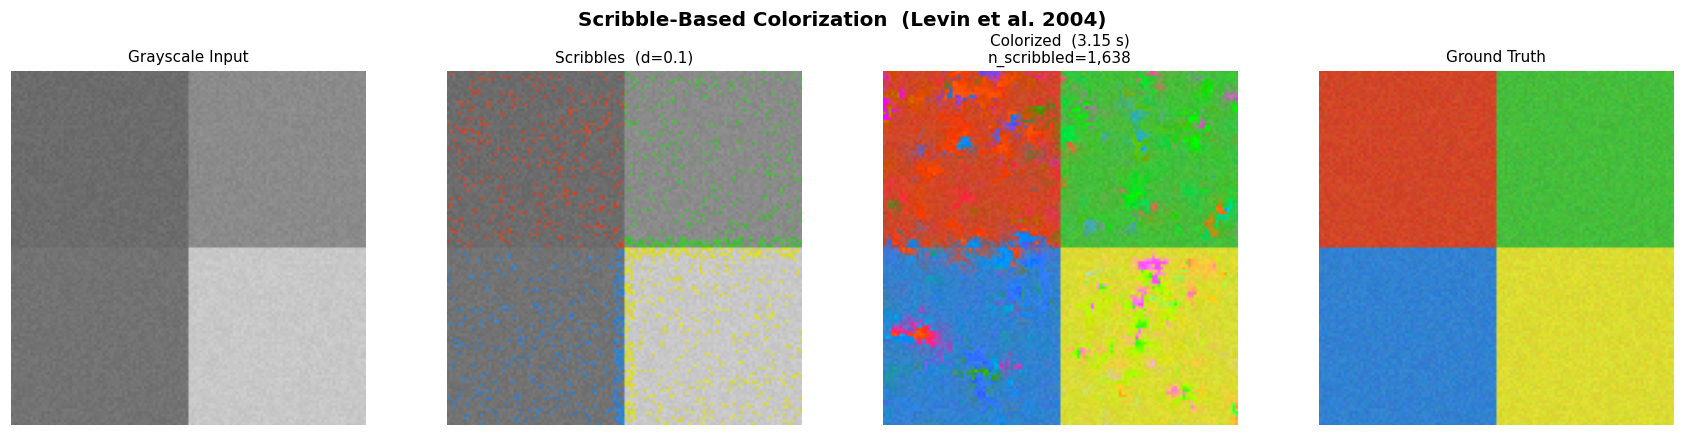

In [31]:
# ── Qualitative comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
panels = [
    (gray_bgr,      'Grayscale Input'),
    (scribble_bgr,  f'Scribbles  (d={DENSITY})'),
    (colorized_bgr, f'Colorized  ({info["time_seconds"]:.2f} s)\n'
                    f'n_scribbled={info["n_scribbled"]:,}'),
    (target_bgr_gt, 'Ground Truth'),
]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('Scribble-Based Colorization  (Levin et al. 2004)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Quality vs Density Trade-off

How does scribble density affect colorization quality? We sweep over several densities and compute PSNR / SSIM.

d=0.005  PSNR=10.64  SSIM=0.1784  t=0.74s
d=0.010  PSNR=16.52  SSIM=0.4033  t=0.74s
d=0.020  PSNR=14.08  SSIM=0.2652  t=0.92s
d=0.050  PSNR=12.90  SSIM=0.2602  t=1.53s
d=0.100  PSNR=15.39  SSIM=0.3356  t=2.74s
d=0.200  PSNR=19.39  SSIM=0.4616  t=5.25s
d=0.400  PSNR=24.70  SSIM=0.6275  t=9.11s


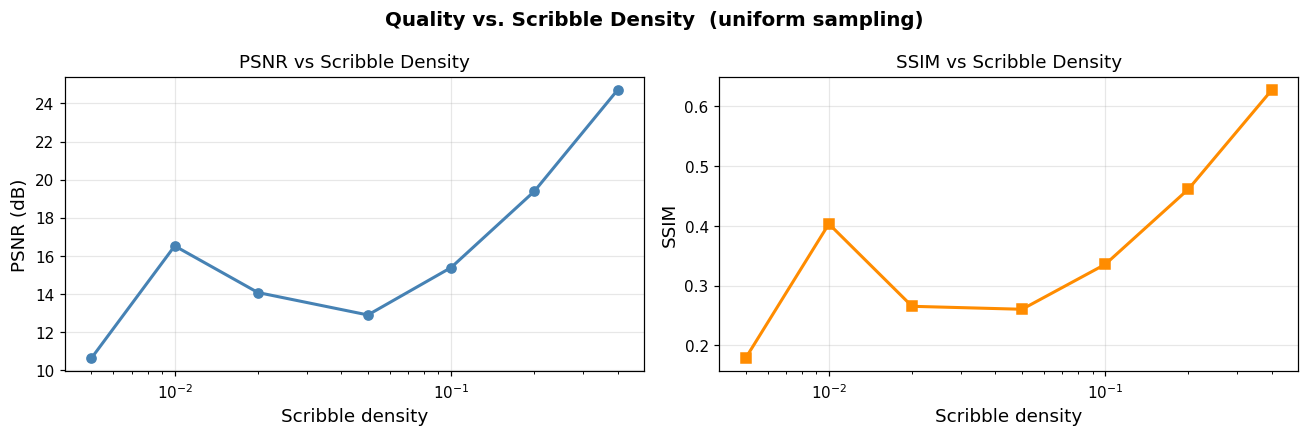

In [20]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

gen       = AutoScribbleGenerator(seed=0)
colorizer = ScribbleColorizer()
gt_rgb    = cv2.cvtColor(target_bgr_gt, cv2.COLOR_BGR2RGB)

sweep_densities = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.40]
psnr_vals, ssim_vals, times = [], [], []

for d in sweep_densities:
    scr = gen.generate(target_bgr_gt, gray_bgr, density=d, mode='uniform')
    out_bgr, meta = colorizer.colorize(gray_bgr, scr)
    out_rgb = cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)
    psnr_vals.append(psnr(gt_rgb, out_rgb, data_range=255))
    ssim_vals.append(ssim(gt_rgb, out_rgb, data_range=255, channel_axis=-1))
    times.append(meta['time_seconds'])
    print(f'd={d:.3f}  PSNR={psnr_vals[-1]:.2f}  SSIM={ssim_vals[-1]:.4f}  t={times[-1]:.2f}s')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.semilogx(sweep_densities, psnr_vals, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('Scribble density', fontsize=12)
ax1.set_ylabel('PSNR (dB)', fontsize=12)
ax1.set_title('PSNR vs Scribble Density', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.semilogx(sweep_densities, ssim_vals, 's-', color='darkorange', linewidth=2)
ax2.set_xlabel('Scribble density', fontsize=12)
ax2.set_ylabel('SSIM', fontsize=12)
ax2.set_title('SSIM vs Scribble Density', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.suptitle('Quality vs. Scribble Density  (uniform sampling)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Affinity Weight Matrix Visualization

A peek at the sparse weight matrix W and its row-sum distribution.

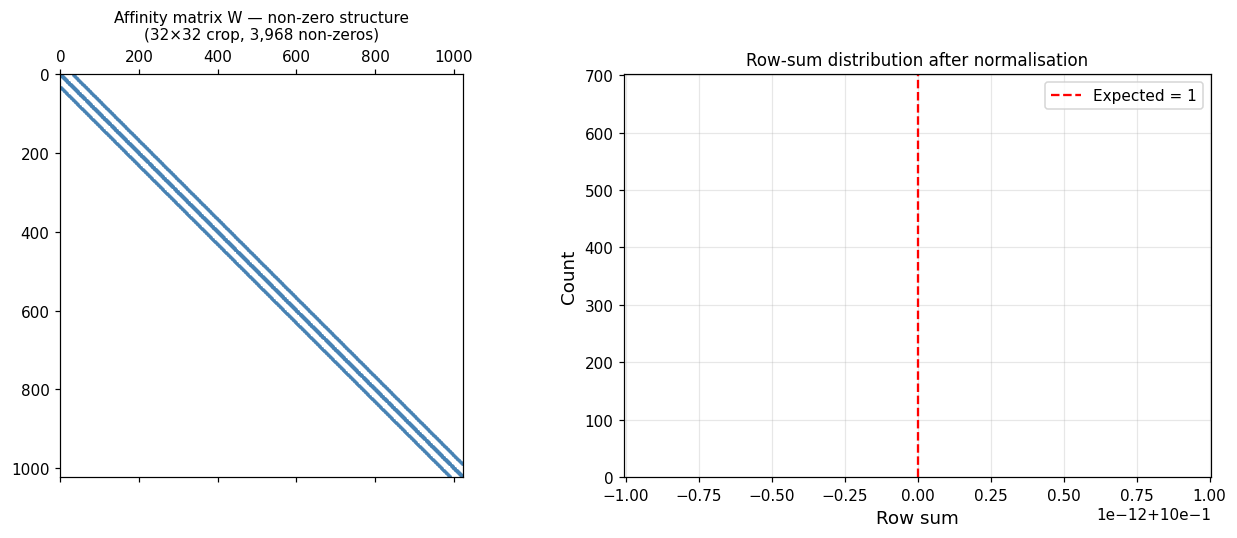

Row-sum stats: mean=1.0000  std=0.0000  min=1.0000  max=1.0000


In [21]:
# ── Weight matrix inspection (small crop for clarity) ─────────────────────────
import matplotlib.colors as mcolors

CROP = 32   # use a small crop to keep the matrix manageable
crop_bgr   = gray_bgr[:CROP, :CROP]
crop_yuv   = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2YUV).astype(np.float64) / 255.0
Y_crop     = crop_yuv[:, :, 0]

_colorizer = ScribbleColorizer()
W_mat      = _colorizer._build_weight_matrix(Y_crop, CROP, CROP)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Spy plot of non-zero structure
axes[0].spy(W_mat, markersize=0.5, color='steelblue')
axes[0].set_title(f'Affinity matrix W — non-zero structure\n'
                  f'({CROP}×{CROP} crop, {W_mat.nnz:,} non-zeros)', fontsize=10)

# Row-sum distribution (should all be ~1 after normalisation)
row_sums = np.asarray(W_mat.sum(axis=1)).ravel()
axes[1].hist(row_sums, bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(1.0, color='red', linestyle='--', label='Expected = 1')
axes[1].set_xlabel('Row sum', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Row-sum distribution after normalisation', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Row-sum stats: mean={row_sums.mean():.4f}  std={row_sums.std():.4f}  '
      f'min={row_sums.min():.4f}  max={row_sums.max():.4f}')

## Summary

| Property | Value |
|---|---|
| Paper | Levin, Lischinski & Weiss — SIGGRAPH 2004 |
| Color space | YUV (Y fixed from grayscale; U,V solved) |
| Affinity | Correlation-based: `w ∝ 1 + (Y(r)−µ)(Y(s)−µ)/σ²` (eq. 3) |
| Solver | `scipy.sparse.linalg.spsolve` (direct sparse LU) |
| Constraints | Hard scribble constraints via row substitution |
| Default window | 3×3 (matches `T=1` → 3×3×3 in paper) |

**Scribble generator modes:**
- `uniform` — random pixel sampling; fast, neutral baseline
- `edge` — biased toward Canny edge regions; better propagation across boundaries

**Limitations:**
- Direct solver scales as O(N^1.5); large images (>512²) are slow — consider multigrid or ILU preconditioner
- Color bleeding occurs at low-contrast boundaries where the affinity cannot differentiate regions
- Quality degrades sharply below ~1% density for complex images